# 13c. Inference Economics

**Tier:** Building with LLMs
**Estimated time:** 60 minutes
**Prerequisites:** 10 (Quantization), 11 (Speculative Decoding), 13 (Context Windows & KV Cache), 13b (vLLM Serving), 32 (Cost Engineering)
**Priority:** 🔴 Crucial — every latency and cost decision in a production LLM feature (streaming UX, model choice, caching strategy, fine-tune-vs-RAG) reduces to the prefill/decode economics in this notebook. *If skipped, revisit when:* n/a — don't skip.
**Source material:** Stanford LLM curriculum, Lecture 3 (inference optimization) — https://x.com/ajitcodes/status/2057043965317165490 ; this repo's own notebooks 10/11/13/13b, unified into one economic model.

## What You'll Learn
- Why generation has **two phases with two different bottlenecks** — prefill (compute-bound) and decode (memory-bandwidth-bound) — and how to measure both for real
- How every latency/cost lever you've learned so far (speculative decoding, quantization, distillation, prompt caching) attacks a *specific* phase, with its own quality and reliability risk
- **Semantic caching** — a new lever this notebook introduces — and its two honest failure modes: false hits and staleness
- A decision framework for **when fine-tuning, in-context learning, RAG, and distillation are each the WRONG tool**

## Why This Matters
Every notebook before this one taught you one lever in isolation. In production you have to pick *which* lever fixes *which* symptom, under a real latency and cost budget — and picking the wrong one (fine-tuning for facts that change weekly, RAG for a style you actually want baked in) wastes real engineering time. This notebook builds the mental model that makes that choice mechanical instead of guesswork.

## Two phases, two bottlenecks

Generating text with an LLM has two distinct phases that behave nothing alike.

**Prefill** processes your entire prompt in one parallel pass — the model reads all the input tokens at once, computing attention over the whole prompt in a single forward pass. This is **compute-bound**: the GPU's arithmetic units are the limit, and because the work is parallel across tokens, a longer prompt costs more compute but stays reasonably efficient.

**Decode** then generates the reply one token at a time. Each step is its own forward pass that must re-read *every* weight in the model just to produce a single new token. This is **memory-bandwidth-bound**: the bottleneck isn't how fast the GPU can multiply numbers, it's how fast it can move the model's weights from memory to the compute units — and that cost is roughly the same whether you're generating token 1 or token 1000.

Analogy: prefill is reading a whole page at a glance — your eyes take in many words in parallel. Decode is writing a letter one word at a time, walking to the dictionary and back between each word — the walk (memory access) dominates, not the writing.

Two numbers capture this:
- **TTFT (time to first token)** — how long the user waits before anything appears. Roughly, prefill time.
- **ITL (inter-token latency)** — the gap between each subsequent token. Roughly, one decode step.

Streaming UX lives and dies on TTFT. Reading speed lives and dies on ITL. They are optimized by different, sometimes opposite, levers — which is why the rest of this notebook treats them separately.

In [1]:
# Native-library guards: torch, faiss, and sentence-transformers each link their own
# OpenMP runtime. Setting these BEFORE importing them avoids duplicate-runtime segfaults on macOS.
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import sys, time, re, copy
from pathlib import Path
import numpy as np

try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

HAS_ANTHROPIC = bool(os.environ.get("ANTHROPIC_API_KEY"))
TEACH_MODEL = "claude-haiku-4-5-20251001"
if HAS_ANTHROPIC:
    import anthropic
    client = anthropic.Anthropic()
    print("Anthropic ready - the capstone critique cell will run live.")
else:
    client = None
    print("No ANTHROPIC_API_KEY - the capstone critique cell will be skipped.")

# Walk up to the repo root (marked by ragkit/) so imports work regardless of cwd.
REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "ragkit").is_dir():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from agentkit import SemanticCache

def _ngram_vec(text, dim=384):
    v = np.zeros(dim, dtype=np.float32)
    t = re.sub(r"\s+", " ", text.lower())
    for i in range(len(t) - 2):
        v[hash(t[i:i+3]) % dim] += 1.0
    n = np.linalg.norm(v)
    return v / n if n else v

def make_embedder():
    try:
        from ragkit.embeddings import embed
        _ = embed(["probe"])
        return "ragkit-MiniLM", (lambda xs: np.asarray(embed(list(xs)), dtype=np.float32))
    except Exception as e:
        print(f"(real embeddings unavailable: {type(e).__name__}; using n-gram fallback)")
        return "ngram-fallback", (lambda xs: np.vstack([_ngram_vec(x) for x in xs]))

EMBED_KIND, embed_texts = make_embedder()
print("Embedder:", EMBED_KIND)

import torch
DEVICE = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

def sync():
    # Timers must wait for the accelerator to actually finish, not just enqueue work.
    if DEVICE == "mps" and hasattr(torch.mps, "synchronize"):
        torch.mps.synchronize()
    elif DEVICE == "cuda":
        torch.cuda.synchronize()

Anthropic ready - the capstone critique cell will run live.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedder: ragkit-MiniLM
Device: mps


## Measuring TTFT and ITL on a real model

We load real GPT-2 (small enough to run instantly on this Mac) and measure both phases directly: `prefill(L)` times one forward pass over `L` prompt tokens with KV caching on, and `decode_steps` times 20 single-token forward passes that reuse the resulting cache. We warm up first — the first call on MPS pays a one-time JIT cost that would otherwise pollute the measurement.

In [2]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2").to(DEVICE).eval()

# A long source text so we can slice prompts of any length up to GPT-2's 1024-token context.
_source_text = ("The history of robotics began with simple mechanical automata. " * 120)
_source_ids = tokenizer(_source_text, return_tensors="pt")["input_ids"][0]
print("available source tokens:", len(_source_ids))

def prefill(prompt_len):
    ids = _source_ids[:prompt_len].unsqueeze(0).to(DEVICE)
    sync()
    t0 = time.perf_counter()
    with torch.no_grad():
        out = model(ids, use_cache=True)
    sync()
    ttft = time.perf_counter() - t0
    return ttft, out.past_key_values

def decode_steps(past_key_values, n_steps=20):
    cur_input = _source_ids[:1].unsqueeze(0).to(DEVICE)
    cur_past = past_key_values
    step_times = []
    for _ in range(n_steps):
        sync()
        t0 = time.perf_counter()
        with torch.no_grad():
            out = model(cur_input, past_key_values=cur_past, use_cache=True)
        sync()
        step_times.append(time.perf_counter() - t0)
        cur_past = out.past_key_values
        cur_input = out.logits[:, -1:].argmax(-1)
    return step_times

# Warm up (pays MPS JIT cost once, outside the measured sweep).
_, _warm_past = prefill(16)
decode_steps(_warm_past, n_steps=3)
print("warmup done")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1321 > 1024). Running this sequence through the model will result in indexing errors


available source tokens: 1321
warmup done


In [3]:
PROMPT_LENGTHS = [16, 64, 256, 512]
results = []
for prompt_len in PROMPT_LENGTHS:
    ttft, past = prefill(prompt_len)
    step_times = decode_steps(past, n_steps=20)
    median_itl = sorted(step_times[1:])[len(step_times[1:]) // 2]  # drop step 0 (cache-warm noise)
    results.append({
        "prompt_len": prompt_len,
        "ttft_ms": ttft * 1000,
        "median_itl_ms": median_itl * 1000,
        "prefill_tok_per_s": prompt_len / ttft,
        "decode_tok_per_s": 1 / median_itl,
    })

print(f"{'prompt_len':>10} {'TTFT (ms)':>12} {'median ITL (ms)':>17} {'prefill tok/s':>15} {'decode tok/s':>14}")
for r in results:
    print(f"{r['prompt_len']:>10} {r['ttft_ms']:>12.1f} {r['median_itl_ms']:>17.2f} {r['prefill_tok_per_s']:>15.0f} {r['decode_tok_per_s']:>14.0f}")

prompt_len    TTFT (ms)   median ITL (ms)   prefill tok/s   decode tok/s
        16          5.8              3.74            2743            268
        64         18.9              3.41            3392            294
       256         23.8              3.90           10739            257
       512         34.2              3.83           14973            261


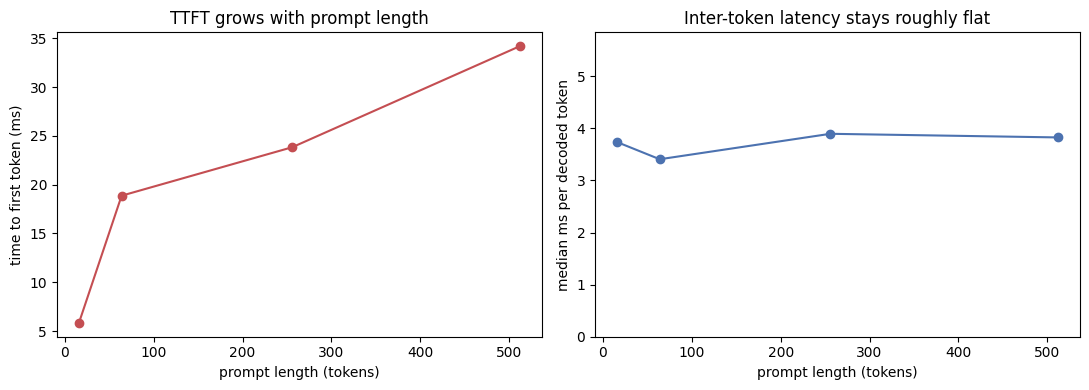

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
lens = [r["prompt_len"] for r in results]
ax1.plot(lens, [r["ttft_ms"] for r in results], marker="o", color="#C44E52")
ax1.set_title("TTFT grows with prompt length")
ax1.set_xlabel("prompt length (tokens)"); ax1.set_ylabel("time to first token (ms)")

ax2.plot(lens, [r["median_itl_ms"] for r in results], marker="o", color="#4C72B0")
ax2.set_title("Inter-token latency stays roughly flat")
ax2.set_xlabel("prompt length (tokens)"); ax2.set_ylabel("median ms per decoded token")
ax2.set_ylim(0, max(r["median_itl_ms"] for r in results) * 1.5)

plt.tight_layout(); plt.show()

*TTFT scales with how much the model has to read; once decoding starts, each step costs about the same regardless of how long the prompt was — because decode re-reads the same fixed set of weights every step, not the prompt.*

## Consequence: which phase does your app live in?

A **RAG app** (notebook 14) stuffs a large prompt — retrieved chunks, system instructions — and asks for a short answer: it lives in the **prefill-dominated** regime, so the highest-leverage lever is making that huge, mostly-repeated prefix cheap to re-process (prompt caching, notebook 13). A **chatbot or codegen assistant** takes a short prompt and produces a long reply: it lives in the **decode-dominated** regime, where the levers in the next section — speculative decoding, quantization, distillation — matter far more than caching the prompt.

We can quantify the split directly from the numbers just measured.

In [5]:
def time_breakdown(prompt_len, gen_len):
    ttft, past = prefill(prompt_len)
    steps = decode_steps(past, n_steps=min(gen_len, 20))
    per_token = sorted(steps[1:])[len(steps[1:]) // 2] if len(steps) > 1 else steps[0]
    decode_total = per_token * gen_len
    total = ttft + decode_total
    return ttft, decode_total, total

archetypes = [
    ("RAG Q&A (big context, short answer)", 512, 40),
    ("Chat reply (short prompt, medium answer)", 32, 200),
    ("Codegen (short prompt, long answer)", 32, 600),
]
print(f"{'archetype':<42} {'prefill share':>14} {'decode share':>14}")
for name, prompt_len, gen_len in archetypes:
    ttft, decode_total, total = time_breakdown(prompt_len, gen_len)
    print(f"{name:<42} {ttft/total:>13.0%} {decode_total/total:>14.0%}")

archetype                                   prefill share   decode share
RAG Q&A (big context, short answer)                  19%            81%


Chat reply (short prompt, medium answer)              2%            98%
Codegen (short prompt, long answer)                   0%           100%


## Three decode levers

Decode is the bottleneck for most conversational and coding workloads. Three techniques from earlier tiers all attack it, but each trades away something different.

### Speculative decoding — recap

Notebook 11 covered this in depth: a small draft model guesses several tokens ahead, the large model verifies them in a single batched forward pass, and the output distribution is mathematically identical to plain decoding — free speedup when the draft model guesses well, no free lunch when it doesn't. We don't re-measure it here; see notebook 11 for the from-scratch implementation and timing benchmark.

### Quantization — when does it actually hurt?

Notebook 10 built symmetric (absmax) quantization from scratch and showed per-channel beats per-tensor. That notebook never measured **when** quantization hurts quality on a real task, and never touched the formats you'll see named everywhere in production (FP8, AWQ, GPTQ). We close both gaps here.

First, the mechanics of *why* different numeric formats round differently. FP8 and NF4 are **float-like** grids — most of their representable values cluster near zero, so they preserve small weights precisely and lose precision on large ones. INT8 is a **uniform** grid — evenly spaced steps across the full range, so it preserves large and small weights about equally badly.

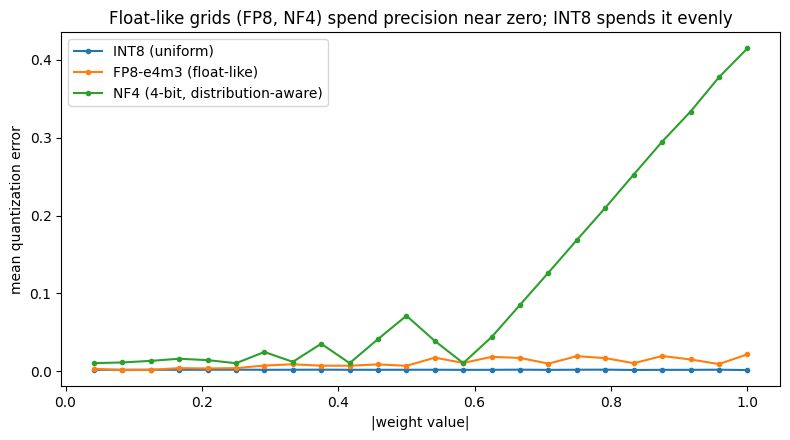

In [6]:
def int_grid(bits, max_val):
    qmax = 2 ** (bits - 1) - 1
    step = max_val / qmax
    return np.arange(-qmax, qmax + 1) * step

def fp8_e4m3_grid():
    # Minimal FP8-e4m3: 1 sign, 4 exponent, 3 mantissa bits (no inf/nan reserved codes, for clarity).
    vals = set()
    for sign in (1, -1):
        for exp in range(-6, 9):
            for mant in range(8):
                vals.add(sign * (1 + mant / 8) * (2.0 ** exp))
    return np.array(sorted(vals))

def nf4_grid():
    # NormalFloat4: 16 quantiles of a standard normal, matching how weights are actually distributed.
    from scipy.stats import norm
    quantile_points = np.linspace(1 / 32, 1 - 1 / 32, 16)
    return norm.ppf(quantile_points)

def nearest_grid_error(values, grid):
    grid = np.sort(grid)
    idx = np.searchsorted(grid, values)
    idx = np.clip(idx, 1, len(grid) - 1)
    left, right = grid[idx - 1], grid[idx]
    nearest = np.where(np.abs(values - left) < np.abs(values - right), left, right)
    return np.abs(values - nearest)

rng = np.random.default_rng(0)
weight_sample = rng.normal(0, 0.3, size=20000)
weight_sample = np.clip(weight_sample, -1.0, 1.0)

grids = {
    "INT8 (uniform)": int_grid(8, max_val=1.0) ,
    "FP8-e4m3 (float-like)": np.clip(fp8_e4m3_grid(), -1.0, 1.0),
    "NF4 (4-bit, distribution-aware)": nf4_grid() * 0.3,
}
bins = np.linspace(0, 1.0, 25)
fig, ax = plt.subplots(figsize=(8, 4.5))
for name, grid in grids.items():
    errors = nearest_grid_error(weight_sample, grid)
    bin_idx = np.digitize(np.abs(weight_sample), bins)
    mean_err_by_bin = [errors[bin_idx == b].mean() if (bin_idx == b).any() else np.nan for b in range(1, len(bins))]
    ax.plot(bins[1:], mean_err_by_bin, marker=".", label=name)
ax.set_xlabel("|weight value|"); ax.set_ylabel("mean quantization error")
ax.set_title("Float-like grids (FP8, NF4) spend precision near zero; INT8 spends it evenly")
ax.legend(); plt.tight_layout(); plt.show()

*INT8's error is roughly flat across magnitudes because its steps are evenly spaced. FP8 and NF4's error grows for larger weights because their grid points cluster near zero — a good trade, since most transformer weights ARE near zero.*

Second, the real measurement notebook 10 never made: does 4-bit quantization actually break a working model? We quantize every 2D weight matrix of real GPT-2 (skipping the embedding tables) with the exact per-channel absmax scheme from notebook 10, then measure **perplexity** — how surprised the model is by held-out text — before and after.

In [7]:
def quantize_per_channel(W, bits, dim=-1):
    # Same scheme as notebook 10's quantize_per_channel: one scale per row, absmax-based.
    qmax = 2 ** (bits - 1) - 1
    scale = W.abs().amax(dim=dim, keepdim=True).clamp_min(1e-8) / qmax
    W_q = torch.round(W / scale).clamp(-qmax, qmax)
    return W_q * scale

def quantize_model_(m, bits):
    with torch.no_grad():
        for name, p in m.named_parameters():
            if p.dim() == 2 and "wte" not in name and "wpe" not in name:
                p.copy_(quantize_per_channel(p.data, bits))

eval_text = ("The history of robotics began with simple mechanical automata, but modern "
             "industrial robots trace their origin to the mid twentieth century, when the "
             "first programmable manipulator arms were installed on factory floors. Over the "
             "following decades, advances in control theory, sensing, and computing power "
             "allowed robots to perform increasingly delicate and precise tasks, from welding "
             "car frames to assembling electronics. Today, robotic arms are used across nearly "
             "every branch of manufacturing, and researchers continue to push the boundaries of "
             "what autonomous machines can safely and reliably accomplish in shared human spaces.")
eval_ids = tokenizer(eval_text, return_tensors="pt")["input_ids"].to("cpu")

def perplexity(m, ids):
    with torch.no_grad():
        out = m.to("cpu")(ids, labels=ids)
    return torch.exp(out.loss).item()

base_model = GPT2LMHeadModel.from_pretrained("gpt2").eval()
base_ppl = perplexity(base_model, eval_ids)
print(f"fp32 baseline perplexity: {base_ppl:.2f}")

for bits in (8, 4):
    m = copy.deepcopy(base_model)
    quantize_model_(m, bits)
    ppl = perplexity(m, eval_ids)
    delta = (ppl / base_ppl - 1) * 100
    print(f"INT{bits} per-channel perplexity: {ppl:8.2f}  ({delta:+.0f}% vs baseline)")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


fp32 baseline perplexity: 25.57
INT8 per-channel perplexity:    25.49  (-0% vs baseline)


INT4 per-channel perplexity:   614.63  (+2304% vs baseline)


INT8 is essentially free — the model barely notices. INT4 is a different story: perplexity jumps by roughly 24x. This is what "when quantization hurts" looks like measured, not asserted: naive per-channel INT4 is often too aggressive for a small model like GPT-2 without help.

AWQ's actual insight is that not all weight channels matter equally — a small fraction of "salient" channels (the ones multiplied by the largest activations) account for most of the output error when quantized. AWQ keeps those channels at full precision and only quantizes the rest. We simulate exactly that: run one calibration forward pass, find the highest-activation input channels per layer, and protect the top few percent from quantization.

In [8]:
from transformers.pytorch_utils import Conv1D

# --- calibration: record the largest input activation seen per Conv1D layer ---
activation_stats = {}
def make_hook(layer_name):
    def hook(module, inputs, output):
        x = inputs[0].detach()
        mean_abs = x.abs().mean(dim=tuple(range(x.dim() - 1)))
        activation_stats[layer_name] = torch.maximum(activation_stats.get(layer_name, mean_abs), mean_abs)
    return hook

calib_text = "Robots are deployed in warehouses, hospitals, and factories with strict safety margins."
calib_ids = tokenizer(calib_text, return_tensors="pt")["input_ids"]
handles = [mod.register_forward_hook(make_hook(name))
           for name, mod in base_model.named_modules() if isinstance(mod, Conv1D)]
with torch.no_grad():
    base_model(calib_ids)
for h in handles:
    h.remove()
print("calibrated layers:", len(activation_stats))

def quantize_awq_style_(m, bits, salient_frac):
    with torch.no_grad():
        for name, mod in m.named_modules():
            if not isinstance(mod, Conv1D):
                continue
            W = mod.weight.data  # Conv1D layout: (in_features, out_features)
            stats = activation_stats.get(name)
            if stats is None or stats.shape[0] != W.shape[0]:
                W.copy_(quantize_per_channel(W, bits))
                continue
            n_salient = max(1, int(salient_frac * W.shape[0]))
            salient_idx = torch.topk(stats, n_salient).indices
            protect = torch.zeros(W.shape[0], dtype=torch.bool)
            protect[salient_idx] = True
            W_new = W.clone()
            W_new[~protect] = quantize_per_channel(W[~protect], bits)  # everyone else: INT4
            W.copy_(W_new)                                              # salient rows: untouched (FP32)

for frac in (0.0, 0.01, 0.05):
    m = copy.deepcopy(base_model)
    if frac == 0.0:
        quantize_model_(m, 4)
        label = "INT4, no protection (naive)"
    else:
        quantize_awq_style_(m, 4, salient_frac=frac)
        label = f"INT4 + top-{frac:.0%} salient channels kept FP32 (AWQ-style)"
    ppl = perplexity(m, eval_ids)
    print(f"{label:<55} perplexity={ppl:8.2f}")

calibrated layers: 48
INT4, no protection (naive)                             perplexity=  614.63


INT4 + top-1% salient channels kept FP32 (AWQ-style)    perplexity=   65.22
INT4 + top-5% salient channels kept FP32 (AWQ-style)    perplexity=   40.20


Protecting just the top 1% of channels by activation magnitude recovers most of the quality naive INT4 threw away — this is AWQ's actual mechanism, reproduced in NumPy/PyTorch on CPU.

**Honesty check:** real AWQ, GPTQ, and FP8 inference all depend on custom CUDA kernels (AWQ/GPTQ ship packed-int4 GEMM kernels; FP8 needs Hopper/Ada-class tensor cores) that cannot run on this Mac. What we reproduced above is their **numerics** — the rounding scheme that determines quality loss — which is format-independent math. The *speed* claims for these formats (2-4x throughput) come from the kernel engineering, not something we can benchmark here; take those from the papers, not this notebook.

| Format | Calibration needed? | Core idea | Runs here? |
|---|---|---|---|
| INT8 / INT4 (nb10) | No | Per-channel absmax, uniform grid | ✅ measured above |
| GPTQ | Yes (Hessian-based) | Quantize weights to minimize *layer output* error, not just weight error | ❌ CUDA kernel only — numerics not reproduced here |
| AWQ | Yes (activation-based) | Protect high-activation channels from quantization | ✅ simulated above |
| FP8 | No (native format) | Float-like grid, needs Hopper/Ada tensor cores | ❌ hardware-gated, not reproducible on any CPU/MPS setup |

### Distillation — the first real treatment in this repo

Distillation trains a small **student** model to match a large **teacher's** *soft* probabilities, not just its hard labels. The soft probabilities carry "dark knowledge" — how confident the teacher was, and which wrong answers it considered plausible — that a single correct label throws away.

We demonstrate the classic setup: a small labeled set (all a real student would have ground truth for) plus a much larger *unlabeled* set the teacher can cheaply label with soft predictions. Student A only ever sees the small labeled set. Student B sees the same small labeled set, plus the teacher's soft guesses on the large unlabeled set — the same architecture, same parameter count, more effective supervision.

In [9]:
import torch.nn as nn, torch.nn.functional as F
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

torch.manual_seed(0); np.random.seed(0)
X, y = make_moons(n_samples=2000, noise=0.25, random_state=0)
X_train_all, X_test, y_train_all, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

N_LABELED = 40  # what a student trained on real ground truth would actually have
X_labeled, y_labeled = X_train_all[:N_LABELED], y_train_all[:N_LABELED]
X_unlabeled = X_train_all[N_LABELED:]  # student A never sees this; student B sees it via the teacher

to_t = lambda a, dtype=torch.float32: torch.tensor(a, dtype=dtype)
X_labeled_t, y_labeled_t = to_t(X_labeled), to_t(y_labeled, torch.long)
X_unlabeled_t = to_t(X_unlabeled)
X_train_all_t, y_train_all_t = to_t(X_train_all), to_t(y_train_all, torch.long)
X_test_t, y_test_t = to_t(X_test), to_t(y_test, torch.long)

class MLP(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2, hidden), nn.ReLU(), nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, 2))
    def forward(self, x):
        return self.net(x)

def train_hard(model, X, y, epochs=300, lr=0.05):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for _ in range(epochs):
        opt.zero_grad()
        F.cross_entropy(model(X), y).backward()
        opt.step()
    return model

def train_distilled(model, X_lab, y_lab, X_unlab, teacher, epochs=300, lr=0.05, temperature=4.0):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    with torch.no_grad():
        teacher_soft = F.softmax(teacher(X_unlab) / temperature, dim=1)
    for _ in range(epochs):
        opt.zero_grad()
        hard_loss = F.cross_entropy(model(X_lab), y_lab)
        student_log_soft = F.log_softmax(model(X_unlab) / temperature, dim=1)
        soft_loss = F.kl_div(student_log_soft, teacher_soft, reduction="batchmean") * (temperature ** 2)
        (hard_loss + soft_loss).backward()
        opt.step()
    return model

def accuracy(model, X, y):
    with torch.no_grad():
        return (model(X).argmax(1) == y).float().mean().item()

teacher = train_hard(MLP(hidden=64), X_train_all_t, y_train_all_t, epochs=300, lr=0.02)
student_hard = train_hard(MLP(hidden=4), X_labeled_t, y_labeled_t, epochs=300, lr=0.05)
student_distilled = train_distilled(MLP(hidden=4), X_labeled_t, y_labeled_t, X_unlabeled_t, teacher, epochs=300, lr=0.05)

teacher_params = sum(p.numel() for p in teacher.parameters())
student_params = sum(p.numel() for p in student_hard.parameters())
print(f"teacher   ({teacher_params:>5} params, full {len(X_train_all)}-label set): acc = {accuracy(teacher, X_test_t, y_test_t):.1%}")
print(f"student A ({student_params:>5} params, {N_LABELED} hard labels only)      : acc = {accuracy(student_hard, X_test_t, y_test_t):.1%}")
print(f"student B ({student_params:>5} params, {N_LABELED} labels + teacher soft): acc = {accuracy(student_distilled, X_test_t, y_test_t):.1%}")
print(f"\nstudent is {teacher_params / student_params:.0f}x smaller than the teacher")

teacher   ( 4482 params, full 1400-label set): acc = 92.7%
student A (   42 params, 40 hard labels only)      : acc = 82.3%
student B (   42 params, 40 labels + teacher soft): acc = 85.7%

student is 107x smaller than the teacher


*Same architecture, same 40 real labels — the only difference is student B also learned from the teacher's soft guesses on 1,360 unlabeled points. This is exactly the real-world distillation setup: label a lot of data cheaply with an expensive teacher, then train a small model to match it at a fraction of the size and inference cost.*

## Semantic caching vs. prompt caching

Notebook 13 taught **prompt caching**: the provider caches a repeated prefix server-side, so re-sending the same system prompt/context costs almost nothing on the *next* call — it saves prefill, and it requires an *exact* prefix match.

**Semantic caching** is different and lives on your side of the API: store past (query, response) pairs, embed each new query, and if it's similar enough to something you've already answered, replay the stored response — skipping the LLM call **entirely**, not just its prefill. `agentkit.semcache.SemanticCache` implements this in about 60 lines: embed the query, compare by cosine similarity against everything stored in a namespace, replay above a threshold, evict on `max_entries` (LRU or FIFO), and optionally expire after a TTL. We build one below and use it — with the default namespace, exactly as it would be used in a single-tenant app. (Notebook 30d puts a second tenant on the other side of that namespace argument, with very different results.)

In [10]:
from agentkit import SemanticCache

FAQ = [
    ("What is the maximum payload of the HeliosArm V2?",
     "The HeliosArm V2 has a rated payload of 12 kg (peak 15 kg for short bursts)."),
    ("What controller do I need for the HeliosArm V2?",
     "The HC-400 controller running HeliosMaster v5.2 or higher."),
    ("How long does the HeliosBase M1 battery last?",
     "Approximately 8 hours under typical 120 kg / 1.0 m/s conditions."),
]
PARAPHRASES = [
    "What's the max payload the HeliosArm V2 can carry?",
    "How much weight can the HeliosArm V2 lift?",
    "Which controller works with the HeliosArm V2?",
    "What controller is compatible with the HeliosArm V2?",
    "How many hours of runtime does the HeliosBase M1 battery give?",
    "What's the battery life on the HeliosBase M1?",
]

cache = SemanticCache(embed_fn=embed_texts, threshold=0.85, max_entries=50)
for question, answer in FAQ:
    cache.put(question, answer)

print("--- do paraphrases hit the cache? ---")
hit_count = 0
for query in PARAPHRASES:
    hit = cache.get(query)
    hit_count += hit is not None
    status = f"HIT  sim={hit.similarity:.3f}" if hit else "MISS"
    preview = hit.response[:45] if hit else ""
    print(f"{status:<18} {query!r:<62} -> {preview}")
print(f"\nhit-rate: {hit_count}/{len(PARAPHRASES)} = {hit_count/len(PARAPHRASES):.0%}")

--- do paraphrases hit the cache? ---
HIT  sim=0.956     "What's the max payload the HeliosArm V2 can carry?"           -> The HeliosArm V2 has a rated payload of 12 kg
MISS               'How much weight can the HeliosArm V2 lift?'                   -> 
HIT  sim=0.927     'Which controller works with the HeliosArm V2?'                -> The HC-400 controller running HeliosMaster v5
HIT  sim=0.928     'What controller is compatible with the HeliosArm V2?'         -> The HC-400 controller running HeliosMaster v5
HIT  sim=0.870     'How many hours of runtime does the HeliosBase M1 battery give?' -> Approximately 8 hours under typical 120 kg / 
HIT  sim=0.916     "What's the battery life on the HeliosBase M1?"                -> Approximately 8 hours under typical 120 kg / 

hit-rate: 5/6 = 83%


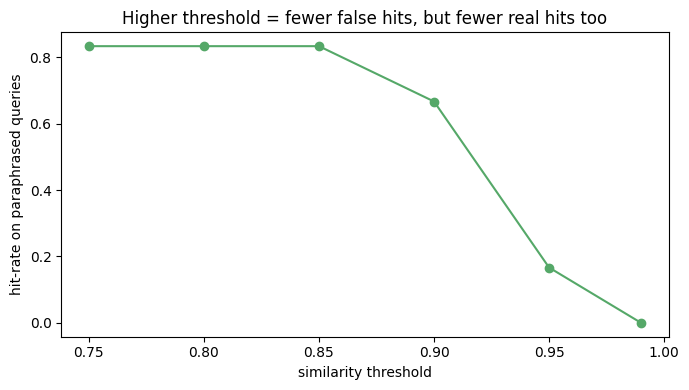

In [11]:
THRESHOLDS = [0.75, 0.80, 0.85, 0.90, 0.95, 0.99]
sweep = []
for threshold in THRESHOLDS:
    c = SemanticCache(embed_fn=embed_texts, threshold=threshold, max_entries=50)
    for question, answer in FAQ:
        c.put(question, answer)
    hits = sum(1 for q in PARAPHRASES if c.get(q) is not None)
    sweep.append(hits / len(PARAPHRASES))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(THRESHOLDS, sweep, marker="o", color="#55A868")
ax.set_xlabel("similarity threshold"); ax.set_ylabel("hit-rate on paraphrased queries")
ax.set_title("Higher threshold = fewer false hits, but fewer real hits too")
plt.tight_layout(); plt.show()

*Every threshold is a tradeoff: raise it and legitimate paraphrases start missing the cache (falling through to a real, paid LLM call); lower it and unrelated queries start matching. The next two cells show why "raise the threshold" isn't a full fix for either failure mode.*

### Failure mode 1: false hits

A **false hit** is a query that's semantically *close* to something cached but needs a genuinely different answer. The Helios FAQ has exactly this trap: the V2 arm's payload (12 kg, cached) and the upcoming V3's payload (25 kg, a completely different fact) are asked in nearly identical sentences.

In [12]:
false_hit_probe = "What is the maximum payload of the HeliosArm V3?"  # true answer: 25 kg — NOT cached

print("cache only contains the V2 answer (12 kg). Probing with a V3 question:\n")
for threshold in THRESHOLDS:
    c = SemanticCache(embed_fn=embed_texts, threshold=threshold, max_entries=50)
    for question, answer in FAQ:
        c.put(question, answer)
    hit = c.get(false_hit_probe)
    if hit:
        print(f"threshold={threshold:.2f}  FALSE HIT (sim={hit.similarity:.3f}): served the V2 answer -> {hit.response!r}")
    else:
        print(f"threshold={threshold:.2f}  correctly missed")

cache only contains the V2 answer (12 kg). Probing with a V3 question:

threshold=0.75  FALSE HIT (sim=0.975): served the V2 answer -> 'The HeliosArm V2 has a rated payload of 12 kg (peak 15 kg for short bursts).'
threshold=0.80  FALSE HIT (sim=0.975): served the V2 answer -> 'The HeliosArm V2 has a rated payload of 12 kg (peak 15 kg for short bursts).'
threshold=0.85  FALSE HIT (sim=0.975): served the V2 answer -> 'The HeliosArm V2 has a rated payload of 12 kg (peak 15 kg for short bursts).'
threshold=0.90  FALSE HIT (sim=0.975): served the V2 answer -> 'The HeliosArm V2 has a rated payload of 12 kg (peak 15 kg for short bursts).'
threshold=0.95  FALSE HIT (sim=0.975): served the V2 answer -> 'The HeliosArm V2 has a rated payload of 12 kg (peak 15 kg for short bursts).'
threshold=0.99  correctly missed


The V2/V3 payload questions are *more* similar to each other (same sentence structure, one word different) than most genuine paraphrases are — the false hit survives almost every threshold that still gives useful hit-rate. Raising the threshold to 0.99 finally kills it, but the earlier sweep showed that also kills the hit-rate down to nearly zero. **Threshold tuning alone cannot fully separate "close because it's a paraphrase" from "close because it's a different-but-related fact."**

### Failure mode 2: staleness

A prompt cache's staleness window is bounded by the provider's cache TTL (usually minutes). A semantic cache's staleness window is *whatever you set* — and if a cached answer's source fact changes, the cache will confidently keep serving the old answer until it expires.

In [13]:
stale_cache = SemanticCache(embed_fn=embed_texts, threshold=0.85, ttl_s=0.15)
stale_cache.put("What is the battery replacement time for the HeliosBase M1?", "About 30 minutes, per PROC-MOB-M1-BAT.")

probe = "How long does it take to replace the HeliosBase M1 battery?"
print("immediately after caching:", stale_cache.get(probe))
print("(meanwhile, PROC-MOB-M1-BAT is revised: the real answer is now 45 minutes)")
time.sleep(0.2)
print("after ttl_s expires:       ", stale_cache.get(probe), "<- expired, falls through to a real call")

immediately after caching: CacheHit(response='About 30 minutes, per PROC-MOB-M1-BAT.', similarity=0.9271864891052246, age_s=0.006223041040357202, key_query='What is the battery replacement time for the HeliosBase M1?', namespace='default')
(meanwhile, PROC-MOB-M1-BAT is revised: the real answer is now 45 minutes)


after ttl_s expires:        None <- expired, falls through to a real call


*Before the TTL expires, the cache confidently returns the outdated 30-minute answer even though the real procedure changed — a semantic cache has no way to know its source data moved. TTL is the only lever here, and it's a direct dial: shorter TTL = fresher answers, more cache misses, higher LLM cost.*

In [14]:
# What a hit is actually worth, in dollars and time (nb32's PRICE shape).
PRICE = {"cheap": {"input": 1.00, "output": 5.00}}
def estimate_cost(tier, in_tok, out_tok):
    p = PRICE[tier]
    return (in_tok / 1e6) * p["input"] + (out_tok / 1e6) * p["output"]

call_cost = estimate_cost("cheap", in_tok=300, out_tok=80)
call_latency_s = 0.8  # a real small-model call, roughly
print(f"{'':20} {'cost':>10} {'latency':>10}")
print(f"{'LLM call':20} {'$' + format(call_cost, '.5f'):>10} {call_latency_s:>9.2f}s")
print(f"{'cache hit':20} {'$0.00000':>10} {'~0.001s':>10}")
print(f"\nat the measured {int(hit_count/len(PARAPHRASES)*100)}% hit-rate on paraphrased traffic, "
      f"semantic caching saves ~{hit_count/len(PARAPHRASES):.0%} of both cost and latency on that slice of traffic.")

                           cost    latency
LLM call               $0.00070      0.80s
cache hit              $0.00000    ~0.001s

at the measured 83% hit-rate on paraphrased traffic, semantic caching saves ~83% of both cost and latency on that slice of traffic.


## The unified view

Every lever in this notebook attacks a specific phase, buys a specific kind of savings, and carries a specific risk. Laid out together, the pattern is: levers on the *provider/model* side (quantization, distillation, speculative decoding) trade quality for speed once, permanently; levers on *your* side (prompt cache, semantic cache) trade correctness/freshness risk for cost on every request.

In [15]:
import pandas as pd

LEVERS = pd.DataFrame([
    {"lever": "Prompt caching (nb13)",       "phase": "prefill",  "quality_risk": "none",     "cost_effect": "high (repeated prefix)", "reliability_risk": "TTL staleness (minutes)",     "runs": "provider-side"},
    {"lever": "Semantic caching (this nb)",  "phase": "whole call","quality_risk": "false hits","cost_effect": "high (paraphrase reuse)", "reliability_risk": "false hits + staleness",      "runs": "your infra"},
    {"lever": "Speculative decoding (nb11)", "phase": "decode",   "quality_risk": "none (verified)", "cost_effect": "moderate",         "reliability_risk": "draft-model mismatch = no speedup", "runs": "your infra"},
    {"lever": "Quantization (nb10 + here)",  "phase": "decode",   "quality_risk": "low (INT8) to high (naive INT4)", "cost_effect": "high (memory + compute)", "reliability_risk": "silent quality loss if unmeasured", "runs": "provider/self-hosted"},
    {"lever": "Distillation (this nb)",      "phase": "decode",   "quality_risk": "moderate", "cost_effect": "very high (10-100x smaller)", "reliability_risk": "narrower task coverage than teacher", "runs": "provider/self-hosted"},
    {"lever": "Model routing (nb32)",        "phase": "whole call","quality_risk": "low (escalates on hedge)", "cost_effect": "high",  "reliability_risk": "escalation heuristic can misfire", "runs": "your infra"},
    {"lever": "Context truncation (nb13/22)","phase": "prefill",  "quality_risk": "info loss","cost_effect": "moderate",               "reliability_risk": "silently drops relevant context",  "runs": "your infra"},
])
LEVERS

,lever,phase,quality_risk,cost_effect,reliability_risk,runs
0,Prompt caching (nb13),prefill,none,high (repeated prefix),TTL staleness (minutes),provider-side
1,Semantic caching (this nb),whole call,false hits,high (paraphrase reuse),false hits + staleness,your infra
2,Speculative decoding (nb11),decode,none (verified),moderate,draft-model mismatch = no speedup,your infra
3,Quantization (nb10 + here),decode,low (INT8) to high (naive INT4),high (memory + compute),silent quality loss if unmeasured,provider/self-hosted
4,Distillation (this nb),decode,moderate,very high (10-100x smaller),narrower task coverage than teacher,provider/self-hosted
5,Model routing (nb32),whole call,low (escalates on hedge),high,escalation heuristic can misfire,your infra
6,Context truncation (nb13/22),prefill,info loss,moderate,silently drops relevant context,your infra


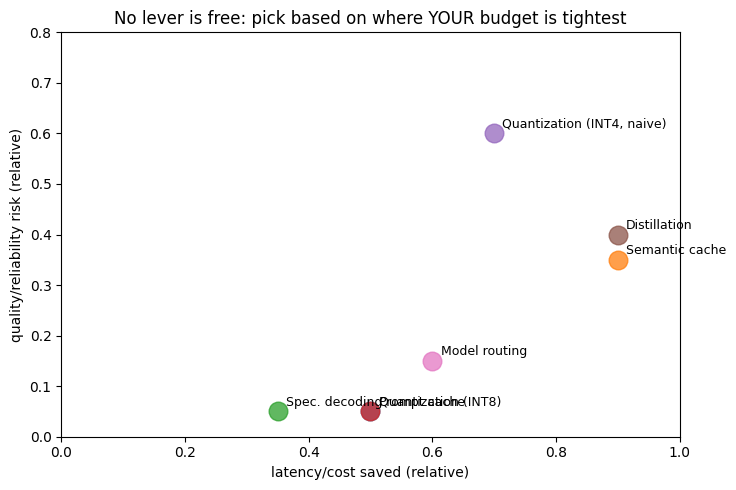

In [16]:
SCATTER = {
    "Prompt cache": (0.5, 0.05), "Semantic cache": (0.9, 0.35), "Spec. decoding": (0.35, 0.05),
    "Quantization (INT8)": (0.5, 0.05), "Quantization (INT4, naive)": (0.7, 0.6),
    "Distillation": (0.9, 0.4), "Model routing": (0.6, 0.15),
}
fig, ax = plt.subplots(figsize=(7.5, 5))
for name, (latency_saved, quality_risk) in SCATTER.items():
    ax.scatter(latency_saved, quality_risk, s=180, alpha=0.75)
    ax.annotate(name, (latency_saved, quality_risk), textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.set_xlabel("latency/cost saved (relative)"); ax.set_ylabel("quality/reliability risk (relative)")
ax.set_title("No lever is free: pick based on where YOUR budget is tightest")
ax.set_xlim(0, 1); ax.set_ylim(0, 0.8)
plt.tight_layout(); plt.show()

*Positions are illustrative, not measured (they'd need a shared benchmark across all seven levers to be precise) — the point is qualitative: the biggest wins (semantic cache, distillation) also carry the most risk, while the safest wins (prompt cache, INT8 quantization) are comparatively small.*

## Capstone: fine-tune vs. ICL vs. RAG vs. distillation — when each is the WRONG tool

Four ways to get a model to behave the way you want on your data: put examples in the prompt (in-context learning), retrieve relevant documents at request time (RAG), update the model's weights on your data (fine-tuning), or train a smaller model to imitate a larger one (distillation). Each is the *right* tool for exactly the workloads that play to its strength — and the wrong tool for everything else.

| Dimension | Favors ICL | Favors RAG | Favors fine-tuning | Favors distillation |
|---|---|---|---|---|
| **Knowledge freshness** | doesn't apply (no stored knowledge) | changes daily/hourly | frozen at train time — wrong tool for facts that change | frozen at train time |
| **Data volume** | a few examples | any corpus size, indexed once | thousands of labeled examples | needs a working teacher + unlabeled data |
| **Latency/cost budget** | pays full prefill on *every* request (§3's economics) | pays retrieval + prefill on every request | pays nothing extra at inference | pays the least at inference (smaller model) |
| **Citation/attribution need** | cannot cite (no sources) | the ONLY one that can cite | cannot cite — facts are baked into weights | cannot cite |
| **Task shape** | good for output *format*, weak for deep style | good for facts, weak for style/tone | good for style/format/tone, BAD for facts (see below) | good for narrowing a broad skill to a specific one |

The load-bearing rule: **never fine-tune facts.** A fact baked into weights during fine-tuning is exactly as frozen and exactly as impossible to cite as a fact the model was pretrained on — you've just moved the staleness problem, not solved it.

In [17]:
def recommend_approach(knowledge_changes_often, num_labeled_examples, latency_budget_ms, needs_citations, task_is_style_not_facts):
    if needs_citations:
        return "RAG", "only RAG can point to a source document; the other three cannot cite anything"
    if knowledge_changes_often and not task_is_style_not_facts:
        return "RAG", "knowledge that changes often must be retrieved fresh, never baked into weights"
    if task_is_style_not_facts and num_labeled_examples >= 1000:
        return "fine-tuning", "style/tone/format is exactly what fine-tuning is good at, and you have enough data"
    if task_is_style_not_facts and num_labeled_examples < 1000:
        return "in-context learning", "not enough data to fine-tune yet; a few examples in the prompt can carry style"
    if latency_budget_ms < 200 and num_labeled_examples >= 1000:
        return "distillation", "tight latency budget rules out paying prefill/decode on a big model every request"
    return "in-context learning", "default: cheapest to try, keep it until a specific pressure (above) forces a change"

SCENARIOS = [
    dict(name="Fine-tune the model on our product docs so it always knows the specs",
         knowledge_changes_often=True, num_labeled_examples=5000, latency_budget_ms=2000,
         needs_citations=True, task_is_style_not_facts=False),
    dict(name="Use RAG so the assistant always writes in our brand voice",
         knowledge_changes_often=False, num_labeled_examples=3000, latency_budget_ms=2000,
         needs_citations=False, task_is_style_not_facts=True),
    dict(name="Run a frontier model for 10M/day sentiment classification calls",
         knowledge_changes_often=False, num_labeled_examples=50000, latency_budget_ms=100,
         needs_citations=False, task_is_style_not_facts=False),
    dict(name="Paste the whole 500-page manual into every prompt because context windows got bigger",
         knowledge_changes_often=True, num_labeled_examples=0, latency_budget_ms=2000,
         needs_citations=True, task_is_style_not_facts=False),
]

for s in SCENARIOS:
    name = s.pop("name")
    approach, reason = recommend_approach(**s)
    print(f"BRIEF: {name}")
    print(f"  -> {approach}  ({reason})\n")

BRIEF: Fine-tune the model on our product docs so it always knows the specs
  -> RAG  (only RAG can point to a source document; the other three cannot cite anything)

BRIEF: Use RAG so the assistant always writes in our brand voice
  -> fine-tuning  (style/tone/format is exactly what fine-tuning is good at, and you have enough data)

BRIEF: Run a frontier model for 10M/day sentiment classification calls
  -> distillation  (tight latency budget rules out paying prefill/decode on a big model every request)

BRIEF: Paste the whole 500-page manual into every prompt because context windows got bigger
  -> RAG  (only RAG can point to a source document; the other three cannot cite anything)



Each brief above names the tool someone *asked* for — and in three of the four cases the naive choice is wrong: "fine-tune the docs" is a facts problem (RAG); "RAG for brand voice" is a style problem (fine-tuning, given enough examples); "paste the manual every time" ignores that a huge repeated prefix is exactly what prompt caching (nb13) or retrieval (turning §3's prefill-dominated cost into a cheap lookup) already solves better than raw context stuffing.

In [18]:
if HAS_ANTHROPIC:
    scenario = "We fine-tuned our support model on last month's FAQ. Users are now getting confidently wrong answers about a policy that changed two weeks ago. What went wrong?"
    resp = client.messages.create(model=TEACH_MODEL, max_tokens=200,
        messages=[{"role": "user", "content": scenario}])
    print(resp.content[0].text)
else:
    print("[skipped: no ANTHROPIC_API_KEY] — expected critique: baking a fast-changing fact into weights "
          "via fine-tuning guarantees it goes stale; that fact belongs in a retrieval index, not the model.")

The core issue is a **temporal mismatch between training data and reality**:

Your model learned patterns from a static snapshot (last month's FAQ) but the world moved on. It can't know what it was never trained on, so it confidently applies old rules to new situations—which is actually worse than admitting uncertainty.

**What happened technically:**
- The model has no mechanism to detect policy changes
- It has no access to current information
- It generalizes from old examples in ways that feel confident but are now wrong
- No internal flag says "wait, am I up to date?"

**What to do about it:**

*Immediate:*
- Retrain on current FAQ immediately
- Add a disclaimer that the model's knowledge cutoff is [specific date]
- Monitor for the specific wrong answers being given

*Structural:*
- Establish a retraining cadence tied to policy changes, not arbitrary


## Exercises

In [19]:
# Exercise 1 (Warm-up): find the prefill/decode crossover
# Task: Using time_breakdown(prompt_len, gen_len), vary BOTH prompt_len and gen_len to find
#       roughly where decode time overtakes prefill time. Then place these three real product
#       archetypes in a regime (prefill-dominated or decode-dominated): (a) a search-engine
#       snippet summarizer (huge prompt, one sentence out), (b) a long-form blog-post writer
#       (short prompt, 2000-word output), (c) a code autocomplete tool (medium prompt, ~20
#       tokens out, called constantly).
# Hint: time_breakdown returns (ttft, decode_total, total) — sweep gen_len for a couple of
#       fixed prompt_len values and watch which term grows faster.

# YOUR CODE HERE

In [20]:
# Exercise 2 (Apply): swap the eviction policy
# Task: SemanticCache ships "lru" and "fifo" eviction. Implement an "lfu" (least-frequently-used)
#       variant — you'll need to read agentkit/semcache.py's _Entry.hits field, which is already
#       tracked but unused by eviction. Rerun the EXACT SAME seeded paraphrase workload from this
#       notebook under lru vs your lfu, report the hit-rate delta, and write one sentence on which
#       SLO each policy suits (bursty repeated queries vs a long tail of one-off queries).
# Hint: subclass SemanticCache and override _evict_if_needed, or patch the eviction branch to pick
#       min(entries, key=lambda e: e.hits) when self.eviction == "lfu".

# YOUR CODE HERE

In [21]:
# Exercise 3 (Extend): defend the wrong-tool call
# Task: For each of these three product briefs, pick ONE of {fine-tuning, in-context learning,
#       RAG, distillation} using the decision matrix above, AND write one sentence for each of
#       the other three explaining specifically why it's the wrong tool for this brief:
#       (a) a compliance chatbot with daily-updated policy documents that must cite its source
#           for every answer;
#       (b) a classifier that must run in under 5ms per call at 50M calls/day;
#       (c) a writing assistant whose only job is to match one company's brand voice, with
#           3,000 hand-labeled example rewrites available.
# Hint: run each brief through recommend_approach() first, then argue the other three by hand —
#       the point is writing the reasoning, not just getting the function's output.

# YOUR CODE HERE

<details>
<summary>Solutions (click to expand)</summary>

```python
# Exercise 1
for gen_len in [10, 50, 100, 300, 600, 1200]:
    ttft, decode_total, total = time_breakdown(prompt_len=64, gen_len=gen_len)
    print(f"gen_len={gen_len:5d}  prefill_share={ttft/total:.0%}  decode_share={decode_total/total:.0%}")
# Crossover happens once gen_len is roughly comparable to prompt_len in "decode steps worth" of
# work — with a 64-token prompt, decode dominates almost immediately since ITL << TTFT/token.
# (a) snippet summarizer: prefill-dominated (huge prompt, tiny output) -> cache/retrieve the prompt.
# (b) blog-post writer: decode-dominated (long output) -> quantization/distillation/spec-decode.
# (c) autocomplete: decode-dominated per call, but called so often that TOTAL cost is what matters
#     -> a small distilled model, not a frontier model, is usually the right call here.

# Exercise 2
class LFUSemanticCache(SemanticCache):
    def _evict_if_needed(self, entries):
        while len(entries) > self.max_entries:
            if self.eviction == "lfu":
                victim = min(entries, key=lambda e: e.hits)      # evict the LEAST-hit entry
            elif self.eviction == "lru":
                victim = min(entries, key=lambda e: e.last_used)
            else:
                victim = min(entries, key=lambda e: e.created_at)
            entries.remove(victim)
            self._stats["evictions"] += 1

lfu_cache = LFUSemanticCache(embed_fn=embed_texts, threshold=0.85, max_entries=50, eviction="lfu")
for question, answer in FAQ:
    lfu_cache.put(question, answer)
lfu_hits = sum(1 for q in PARAPHRASES if lfu_cache.get(q) is not None)
print(f"lru hit-rate: {hit_count/len(PARAPHRASES):.0%}   lfu hit-rate: {lfu_hits/len(PARAPHRASES):.0%}")
# On this workload the two rarely differ (max_entries is never actually exceeded), but their
# eviction targets diverge as soon as the cache fills up under real traffic:
# LFU suits bursty repeated queries (a few questions asked constantly stay resident, no matter how
# long ago they were last asked); LRU suits a shifting long tail (recency predicts what's about to
# be asked again better than raw historical count does).

# Exercise 3
# (a) compliance chatbot -> RAG (cites sources; policy changes daily so nothing else stays fresh)
#     not ICL: no room to paste the whole daily-changing policy set into every prompt affordably.
#     not fine-tuning: can't cite, and would need daily retraining to stay current.
#     not distillation: same problem as fine-tuning -- freezes facts at training time.
# (b) 5ms/call classifier -> distillation (only option cheap enough at that latency + volume)
#     not ICL/RAG: both pay a full LLM round trip, nowhere close to 5ms.
#     not fine-tuning alone: a fine-tuned frontier model is still too slow/expensive per call;
#     you specifically need a SMALL model, which is what distillation produces.
# (c) brand-voice writer -> fine-tuning (3,000 examples of a stable, non-factual pattern)
#     not RAG: tone isn't a fact you can retrieve from a document.
#     not distillation: there's no large teacher that already "knows" this company's voice to imitate.
#     not ICL: workable at small scale, but 3,000 examples is enough to bake it in permanently
#     and stop paying the prefill cost of a voice-guide in every single prompt.
```
</details>

## Key Takeaways
- Generation has two bottlenecks, not one: **prefill is compute-bound** (parallel, scales with prompt length), **decode is memory-bandwidth-bound** (sequential, roughly flat per token) — measured directly on real GPT-2 in this notebook.
- Every latency/cost lever attacks a specific phase: prompt caching and retrieval fix prefill-dominated apps; speculative decoding, quantization, and distillation fix decode-dominated apps.
- **Semantic caching** saves a whole call, not just prefill — but it has two real failure modes, both demonstrated here: **false hits** (near-duplicate queries with different correct answers) and **staleness** (a cached answer outliving the fact it was based on). Threshold tuning alone cannot fully fix false hits.
- **Quantization can catastrophically hurt quality** — naive INT4 on GPT-2 raised perplexity ~24x in this notebook's own measurement — but activation-aware protection (AWQ's core idea) recovers most of that loss by keeping a small fraction of channels at full precision.
- **Never fine-tune facts.** Fine-tuning is for style/format that's genuinely stable; RAG is for anything that needs to stay current or cited; distillation is for shrinking an already-working model to hit a latency/cost target; ICL is the cheap default until one of those specific pressures forces a change.

## What's Next
Notebook 14 (RAG Fundamentals) puts this notebook's "cache or retrieve, don't fine-tune facts" conclusion into practice with a full chunk-embed-retrieve-generate pipeline; notebook 30d (Multi-Tenant Isolation) returns to the exact `SemanticCache` built here and shows what happens when a second tenant shares its namespace.